# <center>EXPLORATORY DATA ANALYSIS - AIRPORT CHECK-IN DATA</center>

In [2]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Loading data
df = pd.read_csv('../data/raw/CK_data.csv',encoding='latin1')

In [5]:
# Evaluating the shape of the data
print(f"Data Shape: {df.shape}")

Data Shape: (17545, 21)


In [8]:
# Initial Overview (Head and Tail)
df.head()

,Date,Start_Time,End_time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,...,Counters,Luggage_In,Luggage_Out,Line_Type,Queue_Agent,PAX_Left,Flight_Cancelled,Heavy_Flow,Continuous_Flow,Carousel_Stoped
0,04/03/2019,13:00:00,14:00:00,Domestic,Azul,13:00:30,13:01:43,0.0,13:01:51,13:05:11,...,4,2,1.0,CK,NaN,NaN,NaN,NaN,NaN,NaN
1,08/03/2019,12:00:00,13:00:00,Domestic,Azul,12:05:03,12:05:10,0.0,12:05:13,12:11:31,...,5,2,1.0,CK,NaN,NaN,NaN,NaN,NaN,NaN
2,11/03/2019,15:00:00,16:00:00,Domestic,Azul,15:50:20,15:50:23,0.0,15:50:26,15:51:49,...,3,2,1.0,CK,NaN,NaN,NaN,NaN,X,X
3,12/03/2019,14:00:00,15:00:00,Domestic,Azul,14:08:22,14:09:06,0.0,14:09:09,14:11:05,...,5,2,1.0,CK,NaN,NaN,NaN,NaN,NaN,NaN
4,13/03/2019,15:00:00,16:00:00,Domestic,Azul,15:33:18,15:33:22,0.0,15:33:25,15:36:15,...,4,2,1.0,CK,NaN,NaN,NaN,NaN,X,X


In [9]:
df.tail()

,Date,Start_Time,End_time,Sector,Airline,Start_Line,End_line,Pax_In_Line,Service_Start,Service_End,...,Counters,Luggage_In,Luggage_Out,Line_Type,Queue_Agent,PAX_Left,Flight_Cancelled,Heavy_Flow,Continuous_Flow,Carousel_Stoped
17540,20/12/2021,18:00:00,19:00:00,Domestic,Azul,18:32:49,18:39:14,0.0,18:39:22,18:41:24,...,3,7,2.0,BD,NaN,NaN,NaN,NaN,NaN,NaN
17541,25/12/2021,10:00:00,11:00:00,Domestic,Azul,09:00:22,09:00:22,0.0,09:00:22,09:31:42,...,4,3,2.0,CK,NaN,NaN,NaN,NaN,NaN,NaN
17542,26/12/2021,07:00:00,08:00:00,Domestic,Latam,07:46:59,07:53:39,0.0,07:53:45,08:06:42,...,5,2,1.0,PR,X,NaN,NaN,NaN,NaN,NaN
17543,30/12/2021,04:00:00,05:00:00,Domestic,Latam,05:01:28,05:01:28,0.0,05:01:28,05:17:44,...,2,2,2.0,BD,NaN,NaN,NaN,NaN,X,NaN
17544,20/12/2021,21:00:00,22:00:00,International,Tap,21:55:16,21:59:43,0.0,21:59:50,22:10:56,...,5,6,2.0,CK,X,NaN,NaN,NaN,NaN,NaN


In [12]:
# Evaluating datatypes and Basic Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17545 entries, 0 to 17544
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              17545 non-null  object 
 1   Start_Time        17545 non-null  object 
 2   End_time          17545 non-null  object 
 3   Sector            17545 non-null  object 
 4   Airline           17545 non-null  object 
 5   Start_Line        17545 non-null  object 
 6   End_line          17545 non-null  object 
 7   Pax_In_Line       17543 non-null  float64
 8   Service_Start     17545 non-null  object 
 9   Service_End       17545 non-null  object 
 10  PAX_Served        17545 non-null  int64  
 11  Counters          17545 non-null  int64  
 12  Luggage_In        17545 non-null  int64  
 13  Luggage_Out       17536 non-null  float64
 14  Line_Type         15555 non-null  object 
 15  Queue_Agent       6220 non-null   object 
 16  PAX_Left          177 non-null    object

In [13]:
# Evaluating Missing Values
missing_values = df.isnull().sum()
print("Missing Values in each column:\n", missing_values)

Missing Values in each column:
 Date                    0
Start_Time              0
End_time                0
Sector                  0
Airline                 0
Start_Line              0
End_line                0
Pax_In_Line             2
Service_Start           0
Service_End             0
PAX_Served              0
Counters                0
Luggage_In              0
Luggage_Out             9
Line_Type            1990
Queue_Agent         11325
PAX_Left            17368
Flight_Cancelled    17495
Heavy_Flow          16764
Continuous_Flow     15618
Carousel_Stoped     17174
dtype: int64


In [15]:
# Percentage of missing values
missing_percentage = (missing_values / len(df)) * 100
print("Percentage of Missing Values in each column:\n", missing_percentage)

Percentage of Missing Values in each column:
 Date                 0.000000
Start_Time           0.000000
End_time             0.000000
Sector               0.000000
Airline              0.000000
Start_Line           0.000000
End_line             0.000000
Pax_In_Line          0.011399
Service_Start        0.000000
Service_End          0.000000
PAX_Served           0.000000
Counters             0.000000
Luggage_In           0.000000
Luggage_Out          0.051297
Line_Type           11.342263
Queue_Agent         64.548304
PAX_Left            98.991166
Flight_Cancelled    99.715019
Heavy_Flow          95.548589
Continuous_Flow     89.016814
Carousel_Stoped     97.885437
dtype: float64


In [16]:
# Descriptive Analytics
df.describe()

,Pax_In_Line,PAX_Served,Counters,Luggage_In,Luggage_Out
count,17543.000000,17545.000000,17545.000000,17545.000000,17536.000000
mean,4.225389,1.822685,5.448333,3.036592,1.670278
std,5.815283,1.022082,2.120963,1.736726,1.201500
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,4.000000,2.000000,1.000000
50%,2.000000,2.000000,5.000000,3.000000,1.000000
75%,6.000000,2.000000,7.000000,4.000000,2.000000
max,65.000000,12.000000,15.000000,25.000000,15.000000


In [18]:
# Categorical Variable Analysis
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
time_cols = ['Date', 'Start_Time', 'End_time', 'Start_Line', 'End_line', 'Service_Start', 'Service_End']
categorical_cols = [col for col in categorical_cols if col not in time_cols]

for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Value counts:")
    print(df[col].value_counts().head(10))


Sector:
  Unique values: 2
  Value counts:
Sector
Domestic         13699
International     3846
Name: count, dtype: int64

Airline:
  Unique values: 13
  Value counts:
Airline
Latam                    4487
Gol                      4350
Azul                     4171
Tap                      1699
Avianca                   760
Air Europa                620
Aerolíneas Argentinas     461
Voe Pass                  410
Cabo Verde                277
Copa Airlines             180
Name: count, dtype: int64

Line_Type:
  Unique values: 10
  Value counts:
Line_Type
CK     9303
 BD    3093
BD     1014
PR      695
 PM     586
 PR     543
 BE     274
PM       34
BE        7
 OS       6
Name: count, dtype: int64

Queue_Agent:
  Unique values: 1
  Value counts:
Queue_Agent
X    6220
Name: count, dtype: int64

PAX_Left:
  Unique values: 1
  Value counts:
PAX_Left
X    177
Name: count, dtype: int64

Flight_Cancelled:
  Unique values: 1
  Value counts:
Flight_Cancelled
X    50
Name: count, dtype: int64



In [19]:
# Date and Time Variable Analysis
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

print(f"\nDate Range: {df['Date_parsed'].min()} to {df['Date_parsed'].max()}")
print(f"Total Days Covered: {(df['Date_parsed'].max() - df['Date_parsed'].min()).days}")


Date Range: 2019-01-02 00:00:00 to 2021-12-31 00:00:00
Total Days Covered: 1094


In [20]:
# Extracting temporal features
df['Year'] = df['Date_parsed'].dt.year
df['Month'] = df['Date_parsed'].dt.month
df['Day_of_Week'] = df['Date_parsed'].dt.dayofweek
df['Day'] = df['Date_parsed'].dt.day
df['Hour'] = pd.to_datetime(df['Start_Time'], format='%H:%M:%S', errors='coerce').dt.hour

In [21]:
# Records by Year
print("\nRecords by Year:")
print(df['Year'].value_counts().sort_index())


Records by Year:
Year
2019    10359
2020     2240
2021     4946
Name: count, dtype: int64


In [22]:
# Records by Month
print("\nRecords by Month:")
print(df['Month'].value_counts().sort_index())


Records by Month:
Month
1     1990
2     1610
3     1640
4      916
5      800
6     1490
7     1570
8     1490
9     1586
10    1610
11    1610
12    1233
Name: count, dtype: int64


In [23]:
# Records by day of the week
print("\nRecords by Day of the Week (0=Monday, 6=Sunday):")
print(df['Day_of_Week'].value_counts().sort_index())


Records by Day of the Week (0=Monday, 6=Sunday):
Day_of_Week
0    2647
1    2432
2    2735
3    2651
4    2949
5    2201
6    1930
Name: count, dtype: int64


In [24]:
# Records by hour of the day
print("\nRecords by Hour of the Day:")
print(df['Hour'].value_counts().sort_index())


Records by Hour of the Day:
Hour
0      120
1      230
2      200
3      180
4      320
5      110
6       94
7      713
8      890
9     1059
10    1270
11    1190
12    1510
13    1240
14    1161
15    1388
16    1374
17     830
18     989
19     901
20    1189
21     291
22     276
23      20
Name: count, dtype: int64


In [25]:
# Duplicated Rows Analysis
duplicated = df.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicated}")

if duplicated > 0:
    print("Duplicated Rows Sample:")
    print(df[df.duplicated(keep=False)].head())


Number of duplicated rows: 1
Duplicated Rows Sample:
            Date Start_Time  End_time    Sector Airline Start_Line  End_line  \
8724  27/10/2021   04:00:00  05:00:00  Domestic    Azul   05:42:13  05:44:59   
8725  27/10/2021   04:00:00  05:00:00  Domestic    Azul   05:42:13  05:44:59   

      Pax_In_Line Service_Start Service_End  ...  Flight_Cancelled  \
8724          0.0      05:48:05    06:10:59  ...               NaN   
8725          0.0      05:48:05    06:10:59  ...               NaN   

      Heavy_Flow  Continuous_Flow  Carousel_Stoped Date_parsed  Year Month  \
8724         NaN              NaN              NaN  2021-10-27  2021    10   
8725         NaN              NaN              NaN  2021-10-27  2021    10   

     Day_of_Week Day Hour  
8724           2  27    4  
8725           2  27    4  

[2 rows x 27 columns]


In [30]:
# Data Quality Checks
print("\nData Quality Checks:")
# Checking for negative values 
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("\nNegative Values in Numeric Columns:\n")
for col in numeric_cols:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f"  {col}: {negative_count} negative values")
    else:
        print(f"  {col}: No negative values")

# Checking for zero values
print("\nZero Values in Numeric Columns:\n")
for col in numeric_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"  {col}: {zero_count} zero values")
    else:
        print(f"  {col}: No zero values")

# Checking for counters range
print("\nCounter Statistics\n")
print(f"Minimun Counters: {df['Counters'].min()}")
print(f"Maximum Counters: {df['Counters'].max()}")
print(f"Mean Counters: {df['Counters'].mean()}")
print(f"Zero Counters: {(df['Counters'] == 0).sum()}")



Data Quality Checks:

Negative Values in Numeric Columns:

  Pax_In_Line: No negative values
  PAX_Served: No negative values
  Counters: No negative values
  Luggage_In: No negative values
  Luggage_Out: No negative values
  Year: No negative values
  Month: No negative values
  Day_of_Week: No negative values
  Day: No negative values
  Hour: No negative values

Zero Values in Numeric Columns:

  Pax_In_Line: 5579 zero values
  PAX_Served: No zero values
  Counters: 5 zero values
  Luggage_In: 62 zero values
  Luggage_Out: 1671 zero values
  Year: No zero values
  Month: No zero values
  Day_of_Week: 2647 zero values
  Day: No zero values
  Hour: 120 zero values

Counter Statistics

Minimun Counters: 0
Maximum Counters: 15
Mean Counters: 5.448332858364206
Zero Counters: 5


In [36]:
# Outlier Detection Using IQR Method
numeric_cols_outlier = ['Pax_In_Line', 'PAX_Served', 'Counters', 'Luggage_In', 'Luggage_Out']

for col in numeric_cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers count: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
   
   # printing the outliers range
    if len(outliers) > 0:
        print(f"  Outlier Range: [{outliers[col].min()}, {outliers[col].max()}]")


Pax_In_Line:
  Q1: 0.0, Q3: 6.0, IQR: 6.0
  Bounds: [-9.00, 15.00]
  Outliers count: 963 (5.49%)
  Outlier Range: [16.0, 65.0]

PAX_Served:
  Q1: 1.0, Q3: 2.0, IQR: 1.0
  Bounds: [-0.50, 3.50]
  Outliers count: 1346 (7.67%)
  Outlier Range: [4, 12]

Counters:
  Q1: 4.0, Q3: 7.0, IQR: 3.0
  Bounds: [-0.50, 11.50]
  Outliers count: 149 (0.85%)
  Outlier Range: [12, 15]

Luggage_In:
  Q1: 2.0, Q3: 4.0, IQR: 2.0
  Bounds: [-1.00, 7.00]
  Outliers count: 426 (2.43%)
  Outlier Range: [8, 25]

Luggage_Out:
  Q1: 1.0, Q3: 2.0, IQR: 1.0
  Bounds: [-0.50, 3.50]
  Outliers count: 1259 (7.18%)
  Outlier Range: [4.0, 15.0]



Correlation Matrix:
              Pax_In_Line  PAX_Served  Counters  Luggage_In  Luggage_Out
Pax_In_Line     1.000000    0.025960  0.193322    0.048502     0.026438
PAX_Served      0.025960    1.000000  0.010511    0.659652     0.496925
Counters        0.193322    0.010511  1.000000    0.011392    -0.032468
Luggage_In      0.048502    0.659652  0.011392    1.000000     0.768642
Luggage_Out     0.026438    0.496925 -0.032468    0.768642     1.000000


,Pax_In_Line,PAX_Served,Counters,Luggage_In,Luggage_Out
Pax_In_Line,1.000,0.026,0.193,0.049,0.026
PAX_Served,0.026,1.000,0.011,0.660,0.497
Counters,0.193,0.011,1.000,0.011,-0.032
Luggage_In,0.049,0.660,0.011,1.000,0.769
Luggage_Out,0.026,0.497,-0.032,0.769,1.000


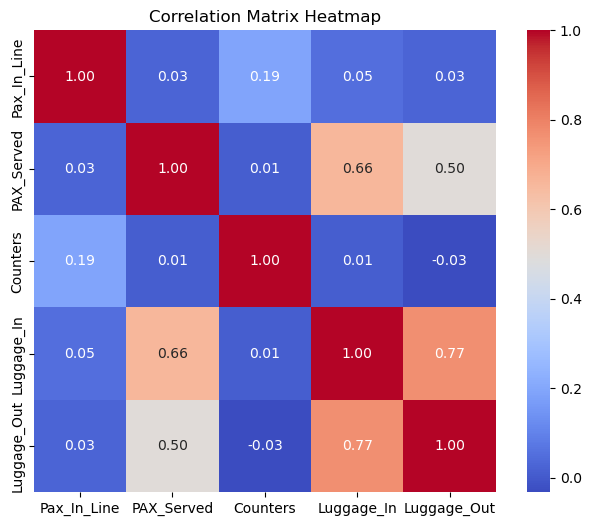

In [37]:
# Correlation Analysis
numeric_df = df[['Pax_In_Line', 'PAX_Served', 'Counters', 'Luggage_In', 'Luggage_Out']].copy()

correlation_matrix = numeric_df.corr()
print("\nCorrelation Matrix:\n", correlation_matrix)
display(correlation_matrix.round(3))

# Visualization of Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [38]:
print("\n--- Strong Correlations (|r| > 0.5) ---")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_value:.3f}")


--- Strong Correlations (|r| > 0.5) ---
PAX_Served <-> Luggage_In: 0.660
Luggage_In <-> Luggage_Out: 0.769
